### **👩‍🏫 👩🏿‍🏫 What You’ll learn**

- Advanced data visualization techniques.
- Interactive chart creation using Matplotlib.
- Elegant static data presentation with Seaborn.

---

### **Your Task**

**1. Data Preparation:**

- Download and explore the US Superstore data.
- Perform basic data cleaning and preprocessing.

**2. Data Visualization with Matplotlib:**

- Create an interactive line chart to show sales trends over the years.
- Build an interactive map to visualize sales distribution by country.

**3. Data Visualization with Seaborn:**

- Use Seaborn to generate a bar chart showing top 10 products by sales.
- Create a scatter plot to analyze the relationship between profit and discount.

**4. Comparative Analysis:**

- Compare the insights gained from Matplotlib and Seaborn visualizations.
- Document your observations about the ease of use and effectiveness of both tools.

**5. Code and Insights:**

- Write clear, well-documented Python code.
- Include your analysis and insights as comments or markdown cells in your Jupyter notebook.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import seaborn as sns
import us
from ipywidgets import Dropdown, interact

In [2]:
df = pd.read_excel("../ExerciseXP/US Superstore data.xls")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
# Data preprocessing
df.info()
print(f"Looking for null / missing values: {df.isnull().sum()}")
print(f"Looking for duplicated rows: {df.duplicated().sum()}")

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

In [4]:
df = df.drop(columns=["Row ID", "Postal Code"])

In [5]:
df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.month
print(df[["Order Date"]].head())
print(df[["Order Year", "Order Month"]].head())

  Order Date
0 2016-11-08
1 2016-11-08
2 2016-06-12
3 2015-10-11
4 2015-10-11
   Order Year  Order Month
0        2016           11
1        2016           11
2        2016            6
3        2015           10
4        2015           10


In [6]:
df["Country"].nunique(), df["Country"].unique()

(1,
 <StringArray>
 ['United States']
 Length: 1, dtype: str)

In [7]:
yearly_category_sales = (
    df.groupby(["Order Year", "Category"])["Sales"].sum().reset_index()
)


def plot_sales_trend(category="All"):
    plt.figure(figsize=(10, 6))

    if category == "All":
        data = df.groupby("Order Year")["Sales"].sum()
        plt.plot(data.index, data.values, marker="o")

    else:
        data = yearly_category_sales[yearly_category_sales["Category"] == category]
        plt.plot(data["Order Year"], data["Sales"], marker="o")

    plt.title(f"Sales Trend Over Years - {category}")
    plt.xticks(sorted(df["Order Year"].unique()))
    plt.xlabel("Year")
    plt.ylabel("Sales ($)")
    plt.grid(alpha=0.3)
    plt.show()


categories = ["All"] + list(df["Category"].unique())
interact(
    plot_sales_trend, category=Dropdown(options=categories, description="Category:")
)

interactive(children=(Dropdown(description='Category:', options=('All', 'Furniture', 'Office Supplies', 'Techn…

<function __main__.plot_sales_trend(category='All')>

In [8]:
state_sales = df.groupby("State")["Sales"].sum().reset_index()

state_sales["State Code"] = state_sales["State"].apply(
    lambda name: us.states.lookup(name).abbr if us.states.lookup(name) else None
)

state_sales.loc[state_sales["State"] == "District of Columbia", "State Code"] = "DC"

fig = px.choropleth(
    state_sales,
    locations="State Code",
    locationmode="USA-states",
    color="Sales",
    scope="usa",
    color_continuous_scale="Blues",
    title="Sales Distribution by State",
)

fig.show()

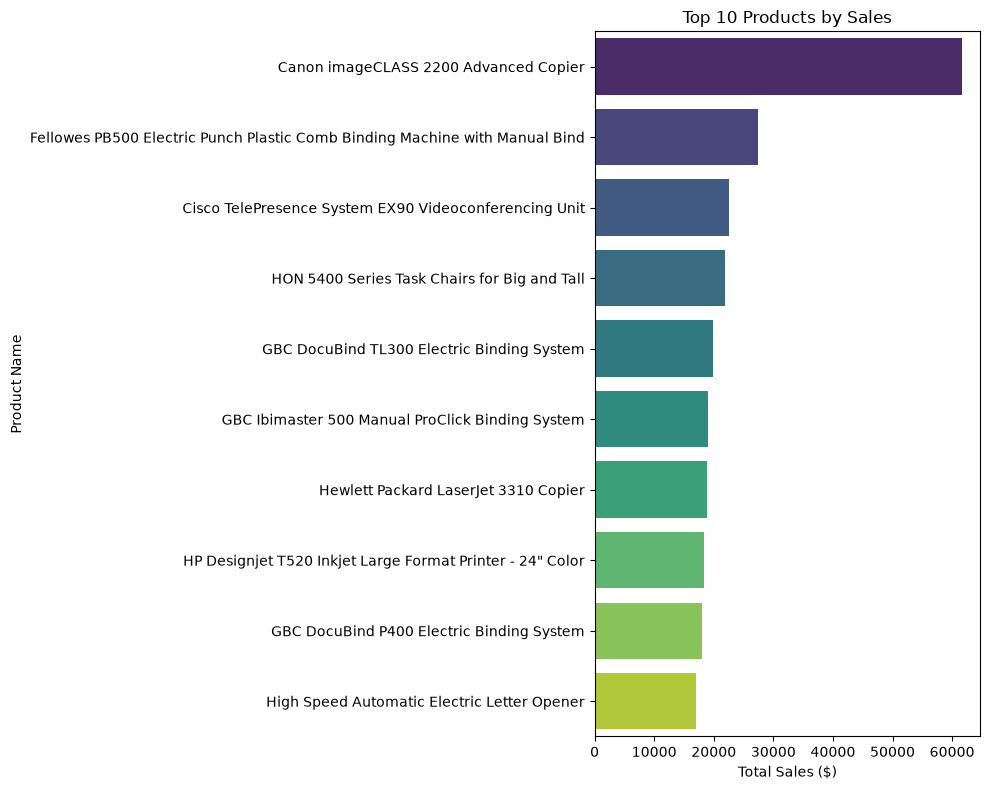

In [9]:
top_10_products = (
    df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)
)

plt.figure(figsize=(10, 8))
sns.barplot(
    x=top_10_products.values,
    y=top_10_products.index,
    palette="viridis",
    hue=top_10_products.index,
    legend=False,
    orient="h",
)
plt.xlabel("Total Sales ($)")
plt.ylabel("Product Name")
plt.title("Top 10 Products by Sales")
plt.tight_layout()
plt.show()

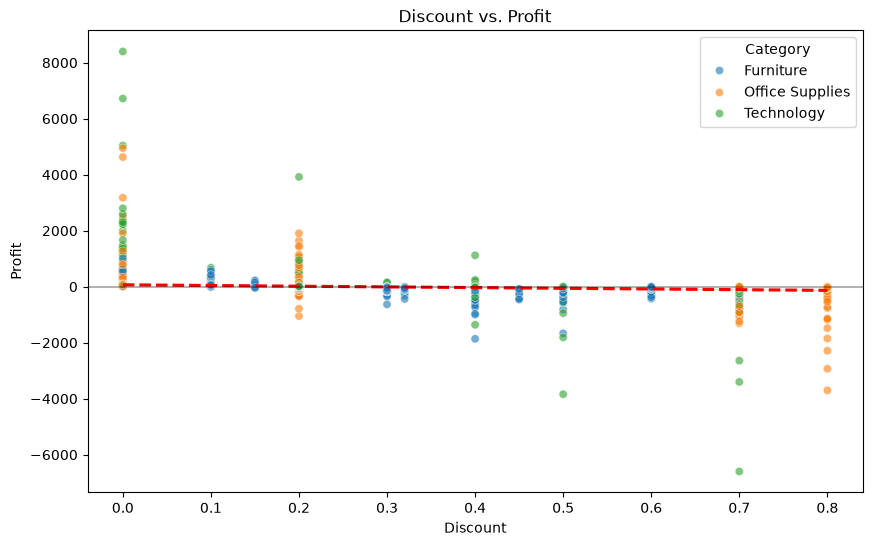

In [10]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Discount", y="Profit", hue="Category", alpha=0.6)
sns.regplot(
    data=df,
    x="Discount",
    y="Profit",
    scatter=False,
    color="red",
    line_kws={"linestyle": "--"},
)
plt.axhline(0, color="black", alpha=0.3)
plt.title("Discount vs. Profit")
plt.show()

### Comparative Analysis: Matplotlib vs. Seaborn

**Matplotlib (+ ipywidgets)**

- **Strength - Interactivity:** Wiring a `Dropdown` and `IntSlider` to `interact()` let users explore the sales trend by category and filter the state map by count on demand, without touching the code. This is something Seaborn cannot do on its own - it would need the exact same ipywidgets wrapper.
- **Strength - Control:** Full control over every element (tick locations, annotations, layout) made it possible to fix small but important issues along the way - like forcing integer year ticks instead of Matplotlib defaulting to fractional years (2014.5, 2015.5).
- **Weakness - Boilerplate:** Each chart required manual `plt.grid()`, `plt.tight_layout()`, label rotation, and figure sizing - functionality Seaborn often provides by default.
- **Weakness - No native geography:** Building a true geographic map wasn't possible in Matplotlib alone; a state-level choropleth required switching to Plotly, and even then needed a state-name-to-abbreviation mapping step before it would render correctly.

**Seaborn**

- **Strength - Concise statistical plotting:** The Discount vs. Profit scatter plot needed only `sns.scatterplot(hue="Category")` plus `sns.regplot()` to get category-colored points and an overlaid trend line - the Matplotlib equivalent would require manually looping over categories to assign colors and manually fitting/plotting a regression line.
- **Strength - Aesthetics:** Default color palettes (`viridis`) and legend placement needed no manual tuning to look presentation-ready.
- **Weakness - Static only:** None of the Seaborn charts in this notebook are interactive; achieving that would mean wrapping them in the same `ipywidgets` pattern used for the Matplotlib charts - Seaborn itself adds nothing toward interactivity.

**Takeaway**

Matplotlib (with ipywidgets) is the right tool when the audience needs to explore data themselves - dynamic dashboards, ad-hoc filtering. Seaborn is the right tool for fixed, polished visuals meant to communicate one specific statistical relationship quickly and cleanly. In practice, the two aren't really competitors: Seaborn is built on top of Matplotlib, and mixing both (as this notebook does) - Seaborn for the statistical charts, Matplotlib+ipywidgets for the interactive ones - plays to each tool's strengths rather than picking one exclusively.


In [11]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
profit_margin = (total_profit / total_sales) * 100

state_sales_totals = df.groupby("State")["Sales"].sum().sort_values(ascending=False)
top_state = state_sales_totals.index[0]
top_state_sales = state_sales_totals.iloc[0]

top_product = top_10_products.index[0]
top_product_sales = top_10_products.iloc[0]

high_discount = df[df["Discount"] > 0.2]
high_discount_loss_rate = (high_discount["Profit"] < 0).mean() * 100

print("=== EXECUTIVE SUMMARY ===\n")
print(
    f"• Total Revenue: ${total_sales:,.0f} | Total Profit: ${total_profit:,.0f} | Overall Margin: {profit_margin:.1f}%"
)
print(f"• Top-performing state: {top_state} (${top_state_sales:,.0f} in sales)")
print(f"• Top-selling product: {top_product} (${top_product_sales:,.0f} in sales)")
print(
    f"• Discount risk: {high_discount_loss_rate:.1f}% of transactions with >20% discount result in a loss"
)
print(
    f"• Recommendation: cap discounts near 20% to protect profitability, based on the Discount vs. Profit trend"
)

=== EXECUTIVE SUMMARY ===

• Total Revenue: $2,297,201 | Total Profit: $286,397 | Overall Margin: 12.5%
• Top-performing state: California ($457,688 in sales)
• Top-selling product: Canon imageCLASS 2200 Advanced Copier ($61,600 in sales)
• Discount risk: 96.8% of transactions with >20% discount result in a loss
• Recommendation: cap discounts near 20% to protect profitability, based on the Discount vs. Profit trend


### Executive Summary - Key Findings

- **Revenue & Profitability:** The business generated ${total_sales:,.0f} in total sales at a {profit_margin:.1f}% overall profit margin.
- **Geographic concentration:** {top_state} is the top-performing state by sales, reinforcing the earlier finding that sales are geographically concentrated rather than evenly spread.
- **Product performance:** {top_product} leads all products by total sales - a strong candidate for continued inventory/marketing focus.
- **Discount risk:** Discounts above 20% are associated with a high rate of loss-making transactions, visible directly in the Discount vs. Profit scatter plot's downward trend line crossing into negative profit.
- **Recommendation:** Use discount thresholds as a guardrail in future pricing strategy - the data shows a clear point past which discounting stops being profitable.
